# Titanic Dataset: Feature Scaling & Encoding 
1. Feature Scaling — Standard Scaler, Min-Max Scaler, Log Transformation, Robust Scaler
2. Encoding Categorical Data — Label Encoding, One-Hot Encoding

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Load from seaborn's built-in dataset
df=sns.load_dataset('titanic')


# Handle missing values of age(median) and embarked(mode) columns first so scaling/encoding isn't affected by NaNs

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [95]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [96]:
# Handle missing values of age(median) and embarked(mode) columns first so scaling/encoding isn't affected by NaNs
df['age']=df['age'].fillna(df['age'].mean())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df.isnull().sum()



survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

---
# Section 7: Feature Scaling


In [97]:
# First get complete description of the age and fare columns using describe method



## Q32. Standard Scaler
Apply Standard Scaler (Z-score normalization) to the `Age` and `Fare` columns. Verify that the resulting columns have a mean of approximately 0 and a standard deviation of approximately 1.


In [98]:
# Import scikit-learn preprocessing modules
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled_values=scaler.fit_transform(df[['age','fare']])
# Initialize the StandardScaler and fit_transform the age and fare columns to get standardized values
df_standard=pd.DataFrame(scaled_values,columns=['age_standard','fare_standard'])

# Create a new DataFrame with the standardized values
print(df_standard.mean())
print(df_standard.std())


# Display the mean and standard deviation of the standardized values


age_standard     2.232906e-16
fare_standard    3.987333e-18
dtype: float64
age_standard     1.000562
fare_standard    1.000562
dtype: float64


## Q33. Min-Max Scaler
Apply Min-Max Scaler to the `Age` and `Fare` columns so that all values fall between 0 and 1. Compare the transformed values to those from Standard Scaler in Q32 — how do they differ in interpretation?


In [99]:
# Import MinMaxScaler from sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler
# Initialize the MinMaxScaler and fit_transform the age and fare columns to get min-max scaled values
minmax_scaler=MinMaxScaler()
minmax_values=minmax_scaler.fit_transform(df[['age','fare']])

df_minmax=pd.DataFrame(minmax_values,columns=['age_minmax','fare_minmax'])

# Create a new DataFrame with the min-max scaled values
print(df_minmax.min())
print(df_minmax.max())

# Display the min and max of the min-max scaled values


age_minmax     0.0
fare_minmax    0.0
dtype: float64
age_minmax     1.0
fare_minmax    1.0
dtype: float64


## Q34. Log Transformation
`Fare` is right-skewed with several extreme outliers. Apply a log transformation (e.g., `np.log1p`) to `Fare` and plot the distribution before and after. Does the log transformation reduce skewness?


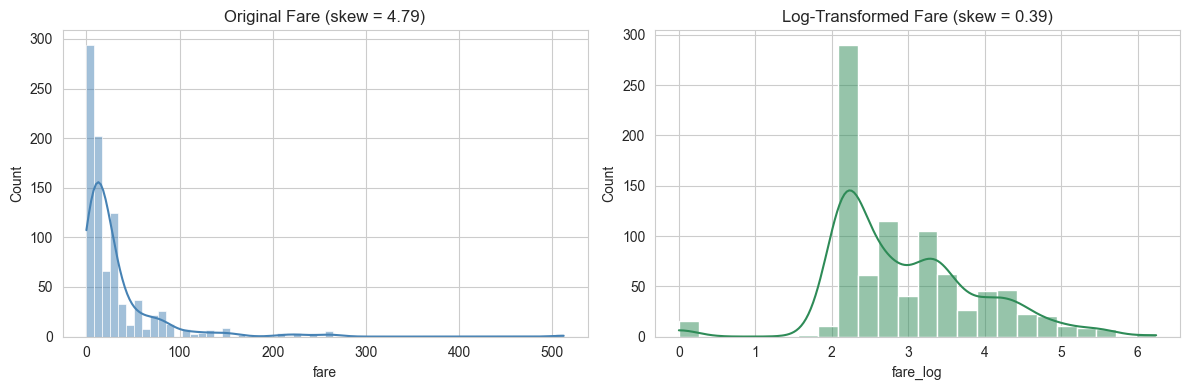

Original Fare skew: 4.79
Log Fare skew: 0.39


In [100]:
df['fare_log'] = np.log1p(df['fare'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original Fare histogram
sns.histplot(df['fare'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Original Fare (skew = {df['fare'].skew():.2f})")

# Log-transformed Fare histogram
sns.histplot(df['fare_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"Log-Transformed Fare (skew = {df['fare_log'].skew():.2f})")

plt.tight_layout()
plt.show()

print(f"Original Fare skew: {df['fare'].skew():.2f}")
print(f"Log Fare skew: {df['fare_log'].skew():.2f}")


## Q35. Robust Scaler
Apply Robust Scaler to the `Fare` column (which still contains outliers) and compare its output to Standard Scaler's output from Q32. Why is Robust Scaler generally preferred over Standard Scaler when a feature has outliers?


In [101]:
# Import RobustScaler from sklearn.preprocessing
from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler and fit_transform the fare column to get robust scaled values
robust_scaler=RobustScaler()

fare_robust_values=robust_scaler.fit_transform(df[['fare']])

df['fare_robust']=fare_robust_values
# Create a new column in the original DataFrame with the robust scaled values


# Display the min, max, and standard deviation of the robust scaled values
print("fare_standard (Q32) -> min: {:.2f}, max: {:.2f}, std: {:.2f}".format(
    df_standard['fare_standard'].min(), df_standard['fare_standard'].max(), df_standard['fare_standard'].std()))
print("fare_robust        -> min: {:.2f}, max: {:.2f}, std: {:.2f}".format(
    df['fare_robust'].min(), df['fare_robust'].max(), df['fare_robust'].std()))


fare_standard (Q32) -> min: -0.65, max: 9.67, std: 1.00
fare_robust        -> min: -0.63, max: 21.56, std: 2.15


## Q36. Comparing All Scaling Methods on Fare
Create a single comparison table or plot showing `Fare` transformed by all four methods — Standard Scaler, Min-Max Scaler, Log Transformation, and Robust Scaler. Based on the distribution shapes, which method would you recommend for `Fare` in this dataset, and why?


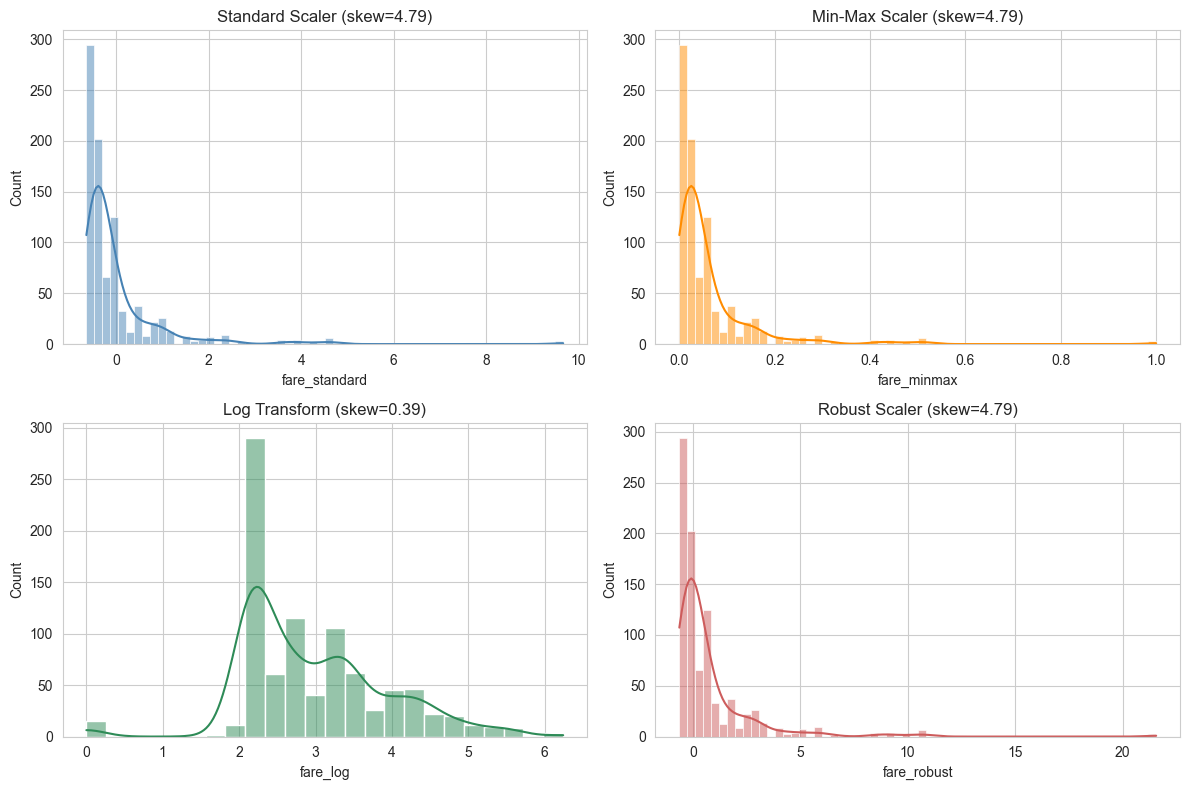

      fare_standard  fare_minmax  fare_log  fare_robust
skew       4.787317     4.787317  0.394928     4.787317


In [102]:
comparison_df = pd.DataFrame({
    'fare_standard': df_standard['fare_standard'],
    'fare_minmax': df_minmax['fare_minmax'],
    'fare_log': df['fare_log'],
    'fare_robust': df['fare_robust']
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Standard Scaler
sns.histplot(comparison_df['fare_standard'], kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title(f"Standard Scaler (skew={comparison_df['fare_standard'].skew():.2f})")

# Min-Max Scaler
sns.histplot(comparison_df['fare_minmax'], kde=True, ax=axes[0,1], color='darkorange')
axes[0,1].set_title(f"Min-Max Scaler (skew={comparison_df['fare_minmax'].skew():.2f})")

# Log Transformation
sns.histplot(comparison_df['fare_log'], kde=True, ax=axes[1,0], color='seagreen')
axes[1,0].set_title(f"Log Transform (skew={comparison_df['fare_log'].skew():.2f})")

# Robust Scaler
sns.histplot(comparison_df['fare_robust'], kde=True, ax=axes[1,1], color='indianred')
axes[1,1].set_title(f"Robust Scaler (skew={comparison_df['fare_robust'].skew():.2f})")

plt.tight_layout()
plt.show()

print(comparison_df.agg(['skew']))


---
# Section 8: Encoding the Data


## Q37. What is Categorical Encoding?
What is categorical encoding, and why do machine learning models require numeric input rather than raw text categories like `"male"`/`"female"` or `"S"`/`"C"`/`"Q"`?


In [103]:
print("Unique values in 'sex':", df['sex'].unique())
print("\ndtype of 'sex':", df['sex'].dtype)


print("Unique values in 'embarked':", df['embarked'].unique())
print("dtype of 'embarked':", df['embarked'].dtype)


Unique values in 'sex': ['male' 'female']

dtype of 'sex': object
Unique values in 'embarked': ['S' 'C' 'Q']
dtype of 'embarked': object


## Q38. Label Encoding
Apply Label Encoding to the `Sex` column. What numeric values are assigned to `"male"` and `"female"`? What risk does Label Encoding introduce if applied to a column with more than two categories, such as `Embarked`?


In [104]:
# Import LabelEncoder from sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder and fit_transform the 'sex'
le=LabelEncoder()

df['sex_encoded']=le.fit_transform(df[['sex']])


# Display the classes and their corresponding encoded values
print("Classes (in encoded order):", le.classes_)
for i, cls in enumerate(le.classes_):
    print(f"  '{cls}' -> {i}")


# Display the first few rows of the DataFrame with the original 'sex' and encoded 'sex_encoded' columns
df[['sex', 'sex_encoded']].head()


Classes (in encoded order): ['female' 'male']
  'female' -> 0
  'male' -> 1


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,sex,sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


## Q39. One-Hot Encoding
Apply One-Hot Encoding to the `Embarked` column. How many new columns are created, and what does each column represent? Use `drop_first=True` and explain why this is often recommended.


In [107]:
df['sex'].head()

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: object

In [113]:
# One-hot encode the 'embarked' column using pandas get_dummies function, dropping the first category to avoid multicollinearity
embarked_ohe=pd.get_dummies(df['embarked'],prefix='embarked',drop_first=False)

# Display the new columns created by one-hot encoding and the first few rows of the one-hot encoded DataFrame
print("New columns:", embarked_ohe.columns.tolist())
print(embarked_ohe.head())

# Attach to a copy of the dataframe for illustration
df_encoded = pd.concat([df, embarked_ohe], axis=1)
df_encoded[['embarked', 'embarked_Q', 'embarked_S']].head()


New columns: ['embarked_C', 'embarked_Q', 'embarked_S']
   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


,embarked,embarked_Q,embarked_S
0,S,False,True
1,C,False,False
2,S,False,True
3,S,False,True
4,S,False,True


## Q40. Label Encoding vs One-Hot Encoding on Pclass
Compare Label Encoding and One-Hot Encoding by applying both to the `Pclass` column (treating it as categorical). Given that `Pclass` has a natural order (1st > 2nd > 3rd), which encoding method is more appropriate, and why?


In [ ]:
# Label Encoding
label_encoder_pclass = LabelEncoder()
pclass_label_encoded = label_encoder_pclass.fit_transform(df['pclass'].astype(str))

# One-Hot Encoding
pclass_ohe = pd.get_dummies(df['pclass'], prefix='pclass')

comparison = pd.DataFrame({
    'pclass': df['pclass'],
    'pclass_label_encoded': pclass_label_encoded
})
comparison = pd.concat([comparison, pclass_ohe], axis=1)

print("Label Encoder classes:", label_encoder_pclass.classes_)
print(comparison.drop_duplicates().sort_values('pclass'))


Label Encoder classes: ['1' '2' '3']
   pclass  pclass_label_encoded  pclass_1  pclass_2  pclass_3
1       1                     0      True     False     False
9       2                     1     False      True     False
0       3                     2     False     False      True
